SUMMARY: I have uploaded two .npz files in the folder "pythia8_data" in mydrive in google drive. The files are QC_jets_1.npz and QC_jets_3.npz. After merging the files,  I have separated the gluons and quarks based on their labels. I have used function "get_total_particles" for the separated arrays for gluons and quarks to get the total number of particles. The outputs I have got are: total gluon particles:  5316391
total quark particles:  3335126
From the relation of transverse momentum and azimuthal angle I have constructed the array four momentum. I have used the function "jet_four_momentum" to construct the four momentum and invarian mass for the gluon jets and quark jets. I have considered eta aprox to rapidity in this notebook. "get_jet_width" and "get_p_T_dispersion" give me the jet observables: jet width and pt dispersion. All the relevant output plots are provided inline.
The boost vector is \beta. Boost, \vec{\beta} = \vec{P}/E.
Boosted momentum (that is momentum in the rest frame), \vec{P'} = Λ * \vec{P}. The Lorentz transformation matrix acts on a four vector to transform it to another frame of reference. the transformation matrix is created with the help of \beta and \vec{p}. I have taken jet 1 for the transformation to the rest frame and constructed the transformation matrix that acts on all the constituents of jet1. "get_lorentz_matrix" gives us Lambda and after acting on gluon or quark data it gives us the four momentum in prime frame or rest frame of a particle. Then i have extracted the \vec{p'} from the four vector. The sum of scalar value of \vec{p'} for jet1 gives us a numpy array with 0 or nan components.
Invariant mass is a lorentz scalar and thus is the same for the rest frame. but the jet width and pt dispersion are not invariant under the lorentz transformation. I have used Lab frame here for the classification. The rest frame can also be used after we transform the four momentum for all the jets and get the other two obserables(jet width and pt dispersion). The transformation hasnt been done in this notebook. I have used the three observables in the lab frame and created a pandas dataframe. I have also added the labels(gluon and quark) in my dataset and then encoded it to binary classes(0 and 1). The input features are the three observables and the target is the binary class. i have scaled my input observables and then divided the data for training and testing. Here, I have used Logistic regression as my classifier model. The auc score, AUC: 0.8246844903682333. The roc curve lies well above the baseline. Using the threshold for probability= 0.5 I have calculated confusion matrix. output: "[[15626  4396]
 [ 5265 14713]]".
using coefficient I have found that the PT_dispersion observable is the most important feature for the classifier.



Data Loading and Exploration

In [ ]:
'''I have uploaded two .npz files in the folder "pythia8_data" in mydrive in google drive. The files are QC_jets_1.npz and QC_jets_3.npz.
the paths of the files are /content/drive/MyDrive/pythia8_data/QG_jets_1.npz and "/content/drive/MyDrive/pythia8_data/QG_jets_3.npz".
This section is not required if the files are already in the same folder as the notebook'''

'''#importing drive files
from google.colab import drive
drive.mount('/content/drive')'''

Mounted at /content/drive


In [ ]:
#headers
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#creating numpy array of the 2 files which are QG_jets_1, QG_jets_3

'''This section assumes that the files QG_jets_1.npz and QG_jets_3.npz are in the same folder as the notebook.
If the files are in any different location, please replace the below with appropriate paths'''

data_1 = np.load("QG_jets_1.npz")
data_3 = np.load("QG_jets_3.npz")

print(data_1.files)   # shows all array names inside
print(data_3.files)


['X', 'y']
['X', 'y']


In [ ]:
#assigning data
X_1=data_1['X']
Y_1=data_1['y']

X_3=data_3['X']
Y_3=data_3['y']

print(X_1.shape)
print(X_3.shape)


(100000, 134, 4)
(100000, 128, 4)


In [ ]:
#merging all the files

max_constituent_len = 134

def pad_array(X, target_len=143):
    pad_len = target_len - X.shape[1]
    return np.pad(
        X,
        pad_width=((0, 0), (0, pad_len), (0, 0)),
        mode='constant',
        constant_values=0
    )

# zero padding all X arrays
X_1_pad = pad_array(X_1, max_constituent_len)
X_3_pad = pad_array(X_3, max_constituent_len)

# merge
X_merged = np.concatenate(
    [ X_1_pad, X_3_pad],
    axis=0
)

Y_merged = np.concatenate(
    [ Y_1, Y_3],
    axis=0
)

print(X_merged.shape)
print(Y_merged.shape)

(200000, 134, 4)
(200000,)


In [ ]:
#separating gluons and quarks
mask_gluon = (Y_merged==0) #gluon condition
mask_quark = (Y_merged==1) #quark condition

X_merged_gluon = X_merged[mask_gluon] #array for gluon
X_merged_quark = X_merged[mask_quark] #array for quark

print(X_merged_gluon.shape)
print(X_merged_quark.shape)

(100000, 134, 4)
(100000, 134, 4)


In [ ]:
def get_total_particles(x):

  mask_exact =  (x[:,:,0] > 0)  #the transverse momentum>0 for existing particles and 0 for constituents occured due to zero padding
  num_particles_per_jet = mask_exact.sum(axis=1) #axis 1 gives us the number of particles
  #print(num_particles_per_jet[:10]) #1st 10 values
  total_particles = num_particles_per_jet.sum() #summing over the number particles for all jets

  return num_particles_per_jet, total_particles

In [ ]:
#number of gluon
gluon_per_jet, total_gluon_particles= get_total_particles(X_merged_gluon)
print("total gluon particles: ",(total_gluon_particles))

#number of quark
quark_per_jet, total_quark_particles= get_total_particles(X_merged_quark)
print("total quark particles: ", (total_quark_particles))


total gluon particles:  5316391
total quark particles:  3335126


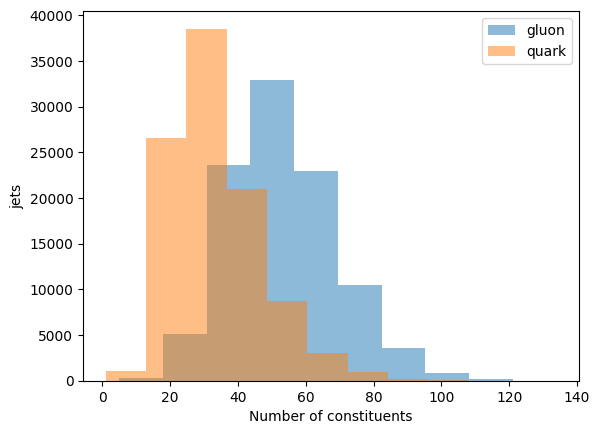

In [ ]:
#histogram for gluons and quarks

plt.hist(gluon_per_jet,alpha=0.5, label='gluon')
plt.hist(quark_per_jet,alpha=0.5, label='quark')

plt.legend()
plt.xlabel("Number of constituents")
plt.ylabel("jets")
plt.show()

Jet Observables

Jet mass:

In [ ]:
def get_pt_y_phi(x):
   pt = x[:,:,0]
   y = x[:,:,1]
   phi = x[:,:,2]
   pt_square = pt**2

   return pt, y, phi, pt_square

In [ ]:

#getting total four momentum  and invariant mass for a jet
def jet_four_momentum(x):
   pt, y, phi, pt_square = get_pt_y_phi(x)
   px = pt * np.cos(phi)
   py = pt * np.sin(phi)
   pz = pt * np.sinh(y)
   E  = pt * np.cosh(y)
   four_mom = np.stack([E, px, py, pz], axis=2) #using c= 1
   print(four_mom.shape)
   jet_four_mom = four_mom.sum(axis=1)
   print(jet_four_mom.shape)
   invariant_mass = np.sqrt(jet_four_mom[:,0]**2 - jet_four_mom[:,1]**2 - jet_four_mom[:,2]**2 - jet_four_mom[:,3]**2)
   print(invariant_mass.shape)

   return jet_four_mom, invariant_mass



In [ ]:
#four momentum and invariant mass for each jet of gluon and quarks
jet_four_mom_gluon, invariant_mass_gluon = jet_four_momentum(X_merged_gluon)
jet_four_mom_quark, invariant_mass_quark = jet_four_momentum(X_merged_quark)


(100000, 134, 4)
(100000, 4)
(100000,)
(100000, 134, 4)
(100000, 4)
(100000,)


/tmp/ipykernel_5511/343781670.py:12: RuntimeWarning: invalid value encountered in sqrt
  invariant_mass = np.sqrt(jet_four_mom[:,0]**2 - jet_four_mom[:,1]**2 - jet_four_mom[:,2]**2 - jet_four_mom[:,3]**2)


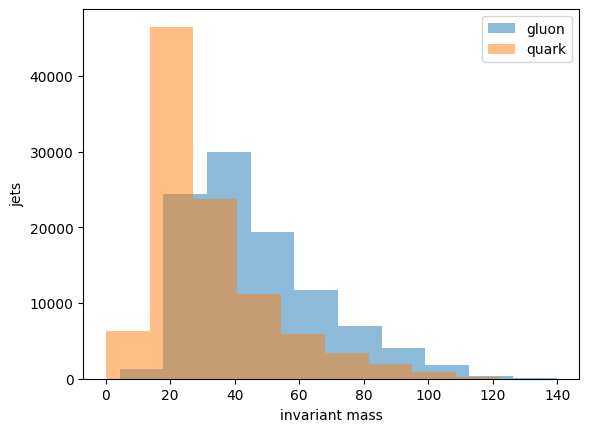

In [ ]:
#plotting invariant mass of each jet of gluons and quarks

#histogram for invariant mass of gluons and quarks

plt.hist(invariant_mass_gluon, alpha=0.5, label='gluon')
plt.hist(invariant_mass_quark,alpha=0.5, label='quark')

plt.legend()
plt.xlabel("invariant mass")
plt.ylabel("jets")
plt.show()

Jet width:

considering \eta \approx y

In [ ]:
def get_pt_eta_phi(x):
   pt = x[:,:,0]
   eta = x[:,:,1]
   phi = x[:,:,2]
   pt_square = pt**2

   return pt, eta, phi, pt_square

In [ ]:
#Eta and phi of central axis
def central_axis(x):

  print((pt * eta).shape)
  print((pt * phi).shape)
  eta_J = (pt * eta).sum(axis=1) / (pt.sum(axis=1))
  phi_J = (pt * phi).sum(axis=1) / (pt.sum(axis=1))
  print(eta_J.shape)
  print(phi_J.shape)

  return  eta_J, phi_J


In [ ]:
#getting eta and phi for the central axis of gluon and quark
pt, eta, phi, pt_square = get_pt_eta_phi(X_merged_gluon)
eta_J_gluon, phi_j_gluon = central_axis(X_merged_gluon)
pt, eta, phi, pt_square = get_pt_eta_phi(X_merged_quark)
eta_J_quark, phi_J_quark = central_axis(X_merged_quark)


(100000, 134)
(100000, 134)
(100000,)
(100000,)
(100000, 134)
(100000, 134)
(100000,)
(100000,)


In [ ]:
#jet width function
def get_jet_width(x):

  eta_J, phi_J = central_axis(x)
  del_R = np.sqrt((eta_J[:,None] - eta)**2 + (phi_J[:, None] - phi)**2)
  print(del_R.shape)
  w= (pt_square*del_R).sum(axis=1)/(pt).sum(axis=1)
  print(w.shape)
  return w

In [ ]:
#getting the jet widths for gluon and quark
pt, eta, phi, pt_square = get_pt_eta_phi(X_merged_gluon)
jet_width_gluon = get_jet_width(X_merged_gluon)
pt, eta, phi, pt_square = get_pt_eta_phi(X_merged_quark)
jet_width_quark = get_jet_width(X_merged_quark)
print("jet width for gluon: ", (jet_width_gluon))
print("jet width for quark: ", (jet_width_quark))

(100000, 134)
(100000, 134)
(100000,)
(100000,)
(100000, 134)
(100000,)
(100000, 134)
(100000, 134)
(100000,)
(100000,)
(100000, 134)
(100000,)
jet width for gluon:  [1.4772538  1.1274668  1.43430264 ... 1.37005712 5.05148101 2.51782033]
jet width for quark:  [0.61641647 0.61313536 0.49153701 ... 0.51293204 0.29984283 5.23802953]


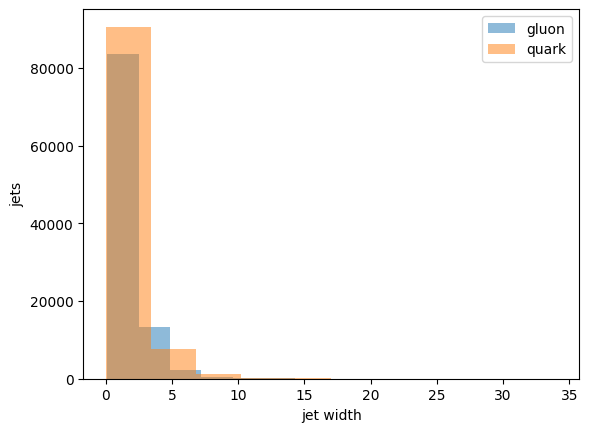

In [ ]:
#plotting histogram for pT width


plt.hist(jet_width_gluon, alpha=0.5, label='gluon')
plt.hist(jet_width_quark, alpha=0.5, label='quark')

plt.legend()
plt.xlabel("jet width")
plt.ylabel("jets")
plt.show()

pT dispersion:

In [ ]:
def get_p_T_dispersion(x):

  p_T_dispersion = ((np.sqrt(pt_square.sum(axis=1))) / (pt.sum(axis=1)))
  print(p_T_dispersion.shape)
  return p_T_dispersion



In [ ]:
#pt dispersion for gluon
pt, eta, phi, pt_square = get_pt_eta_phi(X_merged_gluon)
p_T_dispersion_gluon= get_p_T_dispersion(X_merged_gluon)

#pt dispersion for quark
pt, eta, phi, pt_square = get_pt_eta_phi(X_merged_quark)
p_T_dispersion_quark= get_p_T_dispersion(X_merged_quark)



(100000,)
(100000,)


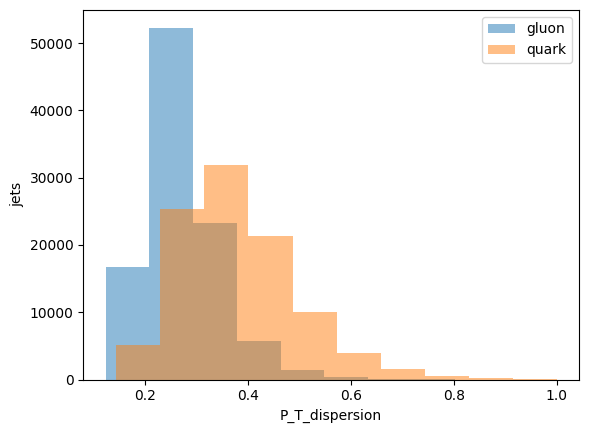

In [ ]:
#plotting histogram for pT dispersion


plt.hist(p_T_dispersion_gluon,alpha =0.5, label='gluon')
plt.hist(p_T_dispersion_quark, alpha=0.5, label='quark')

plt.legend()
plt.xlabel("P_T_dispersion")
plt.ylabel("jets")
plt.show()

Boost to the Jet Center-of-Mass Frame

Boost, \vec{\beta} = \vec{P}/E.
Boosted momentum (that is momentum in the rest frame), \vec{P'} = Λ * \vec{P}

In [ ]:
#constructing beta and lorentz matrix

def get_lorentz_matrix(x):
  pt, y, phi, pt_square = get_pt_y_phi(x)
  px = pt * np.cos(phi)
  py = pt * np.sin(phi)
  pz = pt * np.sinh(y)
  E  = pt * np.cosh(y)
  four_mom = np.stack([E, px, py, pz], axis=2)
  four_mom_jet1= four_mom[0]#considerting only 1st jet
  E1=E[0,:]
  beta= (four_mom_jet1[:,1:])/E1[:,None]
  print(four_mom_jet1.shape)
  print(beta.shape)

  #lorentz matrix

  beta2 = np.sum(beta**2, axis=1)
  gamma = 1.0 / np.sqrt(1.0 - beta2)

  bx = beta[:,0]
  by = beta[:,1]
  bz = beta[:,2]

  #constructing transformation matrix Lambda for the 1st jet

  N = beta.shape[0]
  Lambda = np.zeros((N, 4, 4))  #Lambda is the lorentz transformation matrix for all constituents of jet1

  Lambda[:, 0, 0] = gamma
  Lambda[:, 0, 1] = -gamma * bx
  Lambda[:, 0, 2] = -gamma * by
  Lambda[:, 0, 3] = -gamma * bz

  Lambda[:, 1, 0] = -gamma * bx
  Lambda[:, 2, 0] = -gamma * by
  Lambda[:, 3, 0] = -gamma * bz

  Lambda[:, 1, 1] = 1 + (gamma - 1) * bx * bx / beta2
  Lambda[:, 1, 2] =     (gamma - 1) * bx * by / beta2
  Lambda[:, 1, 3] =     (gamma - 1) * bx * bz / beta2

  Lambda[:, 2, 1] =     (gamma - 1) * by * bx / beta2
  Lambda[:, 2, 2] = 1 + (gamma - 1) * by * by / beta2
  Lambda[:, 2, 3] =     (gamma - 1) * by * bz / beta2

  Lambda[:, 3, 1] =     (gamma - 1) * bz * bx / beta2
  Lambda[:, 3, 2] =     (gamma - 1) * bz * by / beta2
  Lambda[:, 3, 3] = 1 + (gamma - 1) * bz * bz / beta2

  return four_mom_jet1, beta, gamma, Lambda


In [ ]:
#getting momentum for gluon jet1 particles in their rest frames
gluon_p_jet1, gluon_beta, gluon_gamma, gluon_Lambda= get_lorentz_matrix(X_merged_gluon)
p_prime_gluon = gluon_Lambda @ gluon_p_jet1.T
print(p_prime_gluon.shape)
print(p_prime_gluon.sum(axis=2))




(134, 4)
(134, 3)
(134, 4, 134)
[[            nan             nan             nan             nan]
 [            nan             nan             nan             nan]
 [            nan             nan             nan             nan]
 [ 9.86727079e+08 -2.11712083e+08  3.48954810e+08  8.98353417e+08]
 [            nan             nan             nan             nan]
 [            nan             nan             nan             nan]
 [ 7.56973053e+08 -2.39441676e+08  4.08994517e+08  5.90253650e+08]
 [            nan             nan             nan             nan]
 [            nan             nan             nan             nan]
 [            nan             nan             nan             nan]
 [ 1.25669432e+09 -7.05878701e+07  7.19430385e+08  1.02796785e+09]
 [            nan             nan             nan             nan]
 [ 5.43255224e+08 -2.73169988e+07  2.59837054e+08  4.76303186e+08]
 [            nan             nan             nan             nan]
 [            nan             

/tmp/ipykernel_5511/3949031749.py:12: RuntimeWarning: invalid value encountered in divide
  beta= (four_mom_jet1[:,1:])/E1[:,None]
/tmp/ipykernel_5511/3949031749.py:19: RuntimeWarning: invalid value encountered in sqrt
  gamma = 1.0 / np.sqrt(1.0 - beta2)
/tmp/ipykernel_5511/3949031749.py:19: RuntimeWarning: divide by zero encountered in divide
  gamma = 1.0 / np.sqrt(1.0 - beta2)
/tmp/ipykernel_5511/2917455284.py:3: RuntimeWarning: invalid value encountered in matmul
  p_prime_gluon = gluon_Lambda @ gluon_p_jet1.T


In [ ]:
##getting momentum for gluon jet1 particles in their rest frames
quark_p_jet1, quark_beta, quark_gamma, quark_Lambda= get_lorentz_matrix(X_merged_quark)

(134, 4)
(134, 3)


/tmp/ipykernel_5511/3949031749.py:12: RuntimeWarning: invalid value encountered in divide
  beta= (four_mom_jet1[:,1:])/E1[:,None]
/tmp/ipykernel_5511/3949031749.py:19: RuntimeWarning: invalid value encountered in sqrt
  gamma = 1.0 / np.sqrt(1.0 - beta2)
/tmp/ipykernel_5511/3949031749.py:19: RuntimeWarning: divide by zero encountered in divide
  gamma = 1.0 / np.sqrt(1.0 - beta2)


Visualization

Text(0, 0.5, 'py')

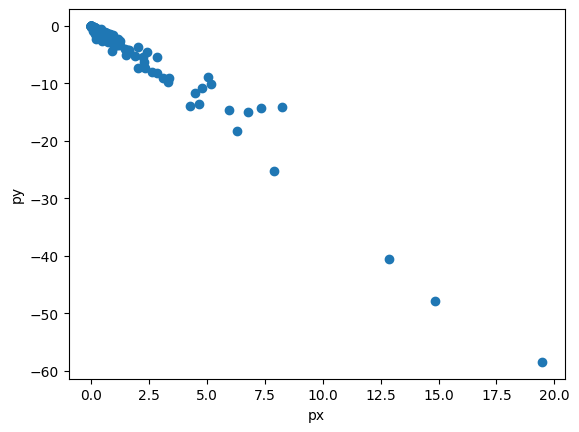

In [ ]:
#gluon px and py in rest frame for jet 1
px_gluon, py_gluon = gluon_p_jet1[:,1], gluon_p_jet1[:,2]
plt.scatter(px_gluon, py_gluon)
plt.xlabel("px")
plt.ylabel("py")


Text(0, 0.5, 'py')

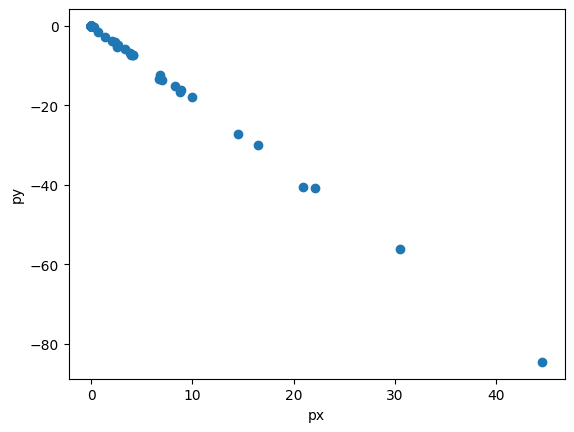

In [ ]:
#quark px and py in rest frame for jet 1
px_quark, py_quark = quark_p_jet1[:,1], quark_p_jet1[:,2]
plt.scatter(px_quark, py_quark)
plt.xlabel("px")
plt.ylabel("py")

Quark vs. Gluon Jet Classification

jet obserables in the rest frame:

invariant mass is a lorentz scalar and thus is the same for the rest frame. but the jet width and pt dispersion are not invariant under the lorentz transformation.

In [ ]:
#headers
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  roc_auc_score, roc_curve, confusion_matrix

lab frame

In [ ]:
#creating pandas dataframe usint the lab frame

#starting with gluon
df= pd.DataFrame({
    'invariant_mass': invariant_mass_gluon,
    'jet_width' : jet_width_gluon,
    'P_T_dispersion' : p_T_dispersion_gluon,
    'label' : 'gluon'
})

#adding quark data to the dataframe's columns
quark_data = pd.DataFrame({
    'invariant_mass': invariant_mass_quark,
    'jet_width' : jet_width_quark,
    'P_T_dispersion' : p_T_dispersion_quark,
    'label' : 'quark'

})
df = pd.concat([df, quark_data], ignore_index=True)
df=df.dropna()
print(df.shape)
print(df.head())

(199999, 4)
   invariant_mass  jet_width  P_T_dispersion  label
0       63.626463   1.477254        0.210653  gluon
1       53.987400   1.127467        0.223363  gluon
2       69.770186   1.434303        0.182594  gluon
3       43.841290   0.672494        0.176804  gluon
4       38.166271   0.803622        0.289410  gluon


In [ ]:
#creating input features and target
X = df.drop(columns=["label"]) #input features
y = df["label"] #target

#encoding target catagories to binary classes of 0 and 1
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(le.classes_) #printing classes assigned to 0 and 1

['gluon' 'quark']


In [ ]:
#splitting data for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
)

In [ ]:
# training and model fitting
model = Pipeline([
    ("scaler", StandardScaler()), #scaling the input features
    ("classifier", LogisticRegression()) #using logistic regression as the classifier
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression())])

In [ ]:
#testing
y_pred = model.predict(X_test)
#creating a dataframe to compare y_test and y_pred
y_data = pd.DataFrame({
    "y_test": y_test,
    "y_pred": y_pred
})
print(y_data.head())

   y_test  y_pred
0       1       1
1       1       1
2       0       0
3       0       0
4       0       1


AUC: 0.8246844903682333


Text(0.5, 1.0, 'ROC Curve')

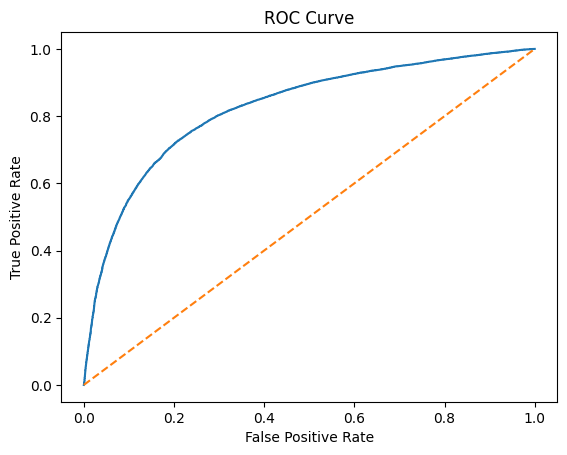

In [ ]:
#getting predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob) #getting auc score
print("AUC:", auc)

#getting fpr and tpr for the roc curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

#plotting the ROC curve
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")



In [ ]:
#getting the confusion matrix with 0.5 threshold
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)#confusion matrix

print(cm)

[[15626  4396]
 [ 5265 14713]]


In [ ]:
#ranking features based on importance using their coeffecient
coef = model.named_steps["classifier"].coef_[0]  #getting coefficeint

#creating a dataframe for the features and their coefficient
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coef,
    "abs_coefficient": np.abs(coef)
})

#sorting absolute coefficient based on descending order
feature_importance = feature_importance.sort_values(
    by="abs_coefficient",
    ascending=False
)

print(feature_importance)

          feature  coefficient  abs_coefficient
2  P_T_dispersion     1.151090         1.151090
0  invariant_mass    -0.717214         0.717214
1       jet_width     0.478034         0.478034
